In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

: 

In [3]:
# setup

transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


In [4]:
# analyze a single input 

for data, target in test_loader:
    image = data
    label = target
    break

print(f"Input shape: {image.shape}")
print(f"Label shape: {label.shape}")

Input shape: torch.Size([1000, 1, 28, 28])
Label shape: torch.Size([1000])



Image tensor shape: torch.Size([1, 28, 28])
Label: 4
Image dtype: torch.float32
Value range: [0.000, 1.000]


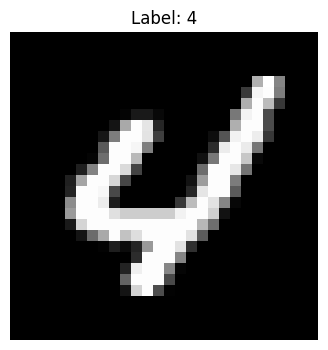

In [5]:
# analyze a single image

for data, target in train_loader:
    image = data[0]
    label = target[0]
    break

print(f"\nImage tensor shape: {image.shape}")  # [channels, height, width]
print(f"Label: {label}")
print(f"Image dtype: {image.dtype}")
print(f"Value range: [{image.min():.3f}, {image.max():.3f}]")

# Visualize
plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.axis('off')
plt.show()


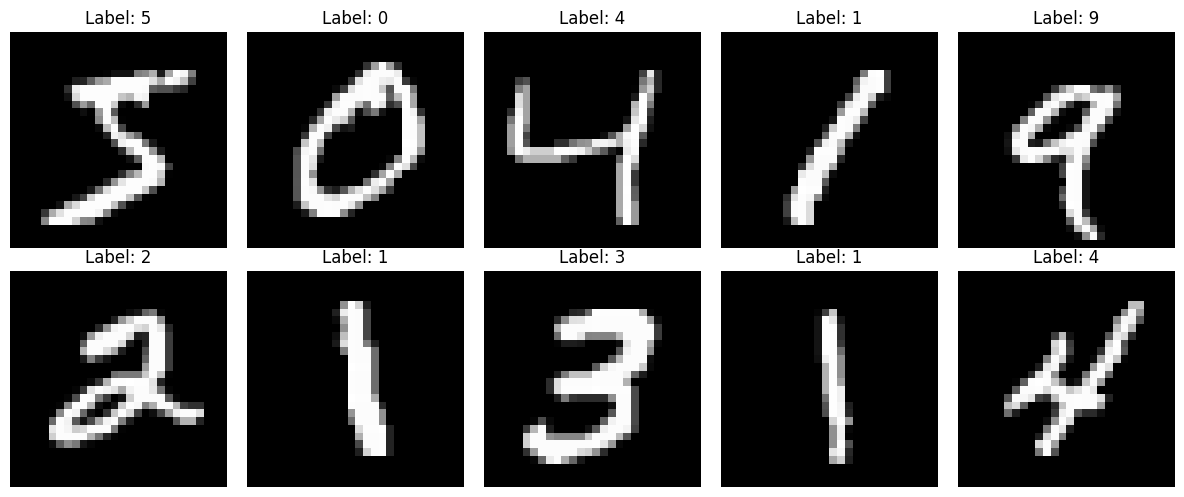

In [6]:
# Visualize multiple images

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()



In [ ]:
# Simple neural network
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


learning_rate = 0.001

# Load data
transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Setup
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#model = Net().to(device)
model = Net()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Train
for epoch in range(5):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        #data, target = data.to(device), target.to(device)

        optimizer.zero_grad()


        output = model(data)

        
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}')

# Test
model.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        #data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f'Test Accuracy: {100. * correct / len(test_dataset):.2f}%')

Epoch 0, Batch 0, Loss: 2.3241
Epoch 0, Batch 100, Loss: 0.2641
Epoch 0, Batch 200, Loss: 0.3273
Epoch 0, Batch 300, Loss: 0.2145
Epoch 0, Batch 400, Loss: 0.2728
Epoch 0, Batch 500, Loss: 0.4921
Epoch 0, Batch 600, Loss: 0.1565
Epoch 0, Batch 700, Loss: 0.1533
Epoch 0, Batch 800, Loss: 0.1716
Epoch 0, Batch 900, Loss: 0.2160
Epoch 1, Batch 0, Loss: 0.3891
Epoch 1, Batch 100, Loss: 0.1106
Epoch 1, Batch 200, Loss: 0.1633
Epoch 1, Batch 300, Loss: 0.2396
Epoch 1, Batch 400, Loss: 0.2138
Epoch 1, Batch 500, Loss: 0.1060
Epoch 1, Batch 600, Loss: 0.0763
Epoch 1, Batch 700, Loss: 0.1473
Epoch 1, Batch 800, Loss: 0.1660
Epoch 1, Batch 900, Loss: 0.0842
Epoch 2, Batch 0, Loss: 0.1671
Epoch 2, Batch 100, Loss: 0.0568
Epoch 2, Batch 200, Loss: 0.1302
Epoch 2, Batch 300, Loss: 0.0267
Epoch 2, Batch 400, Loss: 0.0744
Epoch 2, Batch 500, Loss: 0.2021
Epoch 2, Batch 600, Loss: 0.0309
Epoch 2, Batch 700, Loss: 0.0378
Epoch 2, Batch 800, Loss: 0.0992
Epoch 2, Batch 900, Loss: 0.1145
Epoch 3, Batch 0